# Deep Learning - Demo I

## Table of contents

1. Neural Networks

    1.1 Multilayer neural networks

2. Deep Learning in `keras`

    2.1 Keras optimizer

## 1. Neural Networks



![image.png](https://education-team-2020.s3.eu-west-1.amazonaws.com/ai-eng/NeuralNetwork.png)

Neural nets are a specific method for learning from data, a method that is based on a very simple element, the *neuron unit*. A neuron unit (or 1-layer neural network) is a mathematical function of this kind:

${\mathbf y} = \sigma(\mathbf{w}^T \cdot {\mathbf x} + b)$

where ${\mathbf x}$ represents an input element in vector form, $\mathbf{w}$ is a vector of weights,  $\sigma$ is a non-linear function and $b$ a scalar value. $(\mathbf{w},b)$ are called the parameters of the function. The output of this function is called the *activation* of the neuron. 

Regarding the non-linear function, historically the most common one was the Sigmoid function, but nowadays there are several alternatives that are supposed to be better suited to learning from data, such as ReLU and variants.

> **Question:** What kind of decision functions are represented by a 1-layer nn?

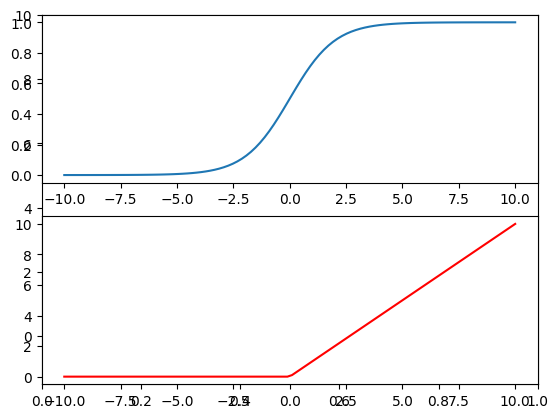

In [1]:
import numpy as np
import matplotlib.pylab as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLU(x):
    return x * (x > 0)

plt.ylim(-1.5, 10)
x = np.linspace(-10.0,10.0,100)
y1 = sigmoid(x)
plt.subplot(2, 1, 1)
plt.plot(x,y1)
y2 = ReLU(x)
plt.subplot(2, 1, 2)
plt.plot(x,y2,'r')

In [2]:
# Example of an input vector: a single data sample with 3 features
x = np.array([0.4, 1.2, 3.5])

# Weights: one per feature, learned during training
w = np.array([1.0, 2.0, 1.0])

# Bias: shifts the decision boundary
b = 1.3


# Neuron output: y = sigmoid(w·x + b)
y = ReLU(np.dot(x,w) + b)

print(f"Before activation function: {np.dot(x,w) + b}")
print(y)

Before activation function: 7.6
7.6


<br>

## 1.1 Multilayer neural networks

Simple neurons can be organized in larger structures by applying to the same data vector different sets of weights, forming what is called a *layer*, and by stacking layers one on top of the output of the other.  

It is important to notice that a multilayer neural network can be seen as a composition of matrix products (matrices represent weights) and non-linear function activations. For the case of a 2-layer network the outcome is:

$ {\mathbf y} = {\mathbf \sigma}\Big( W^1  {\mathbf \sigma}\Big( W^0  {\mathbf x} + {\mathbf b}^0 \Big) + {\mathbf b}^1 \Big)$

where ${\mathbf \sigma}$ represents a vectorial version of the sigmoid function and $W^i$ are the weights of each layer in matrix form.  

What is interesting about this kind of structures is that it has been showed that even a neural network with a single hidden layer containing a finite number of neurons can approximate any continuous function of $\mathbf{R}^n$. This fact makes neural networks a sound candidate to implement learning from data methods. The question is then: how to find the optimal parameters, ${\mathbf w} = (W^i,{\mathbf b})$, to approximate a function that is implicitly defined by a set of samples $\{({\mathbf x}_1, {\mathbf y}_1), \dots,  ({\mathbf x}_n, {\mathbf y}_n)\}$?

From a technical point of view, not only neural networks but most of the algorithms that have been proposed to infer models from large data sets are based on the iterative solution of a mathematical problem that involves data and a mathematical model. If there was an analytic solution to the problem, this should be the adopted one, but this is not the case for most of the cases. The techniques that have been designed to tackle these problems are grouped under a field that is called optimization. The most important technique for solving optimization problems is *gradient descend*.

> The training of models like $ {\mathbf y} = {\mathbf \sigma}\Big( W^1  {\mathbf \sigma}\Big( W^0  {\mathbf x} + {\mathbf b}^0 \Big) + {\mathbf b}^1 \Big)$ (or bigger!) can be readily performed by applying *automatic differentiation* to a loss function. 

> In the case of regression: $L = \frac{1}{n} \sum_{i=1}^n \Big({\mathbf y}_i - {\mathbf \sigma}\Big( W^1  {\mathbf \sigma}\Big( W^0  {\mathbf x}_i + {\mathbf b}^0 \Big) + {\mathbf b}^1 )\Big)\Big)^2 $

> In the case of two-class classification: $L = \frac{1}{n} log(1 + exp(-y_i {\mathbf \sigma}\Big( W^1  {\mathbf \sigma}\Big( W^0  {\mathbf x} + {\mathbf b}^0 \Big) + {\mathbf b}^1 \Big))) $


## Playing with neural nets.

+ Concentric classes, 1 layer, Sigmoid.
+ Concentric classes, 1 layer, ReLu.
+ X-or, 0 layer.
+ X-or, 1 layer.
+ Spiral data.
+ Regression.


http://playground.tensorflow.org

<br>

## 2. Deep Learning in `keras`

<br>

> Keras is a high-level neural networks library, written in Python and capable of running on top TensorFlow. It was developed with a focus on enabling fast experimentation.

<br>


The core data structure in Keras is a model, which defines how layers are organized and connected. 

<br>

### 2.1 Syntax

The simplest and most common type is the `Sequential` model, which represents a straightforward linear stack of layers, where each layer has exactly one input and one output.


<br>

```Python
from tensorflow.keras.models import Sequential
model = Sequential()
```

<br><br>

Stacking layers is as easy as ``.add()``:

```Python
from tensorflow.keras.layers import Dense, Activation

model.add(Dense(output_dim=64, input_dim=100))
model.add(Activation("relu"))
model.add(Dense(output_dim=10))
model.add(Activation("softmax"))

# Explanation:
# - Fully connected layer: takes input vector of size 100 and outputs 64 features (64 neurons)
# - Applies ReLU activation to introduce non-linearity
# - Fully connected layer: takes 64 inputs (inferred) and outputs 10 values (e.g., class scores)
# - Converts outputs into probabilities that sum to 1 (multi-class classification)

```

<br><br>

Once your model looks good, configure its learning process with ``.compile()``:

```Python
model.compile(loss='categorical_crossentropy', 
              optimizer='sgd', metrics=['accuracy'])

# Explanation:
# - Trains the model to minimize cross-entropy loss using SGD, while reporting accuracy as a performance metric (not optimized directly)
```

<br><br>

If you need to, you can further configure your optimizer.

```Python
from tensorflow.keras.optimizers import SGD

model.compile(loss='categorical_crossentropy', optimizer=SGD(lr=0.01, momentum=0.9, nesterov=True))

# Minimizes categorical cross-entropy using SGD with learning rate 0.01; momentum (0.9) helps smooth and accelerate updates in consistent directions, and Nesterov momentum improves the gradient estimate for more stable convergence.
```

<br><br>

You can now iterate on your training data in batches:

```Python
model.fit(X_train, Y_train, nb_epoch=5, batch_size=32)

# Trains the model on the training data for 5 epochs, updating weights in mini-batches of 32 samples per step.
```

<br><br>

Evaluate your performance in one line:
```Python
loss_and_metrics = model.evaluate(X_test, Y_test, batch_size=32)

# Evaluates the trained model on test data using batches of 32 samples, returning the loss value and any metrics (e.g., accuracy) defined during compilation.
```

<br><br>

Or generate predictions on new data:

```Python
classes = model.predict_classes(X_test, batch_size=32)
proba = model.predict_proba(X_test, batch_size=32)
```

<br><br>

### 2.2 Let's see a demo

In [3]:
import tensorflow as tf

# Check whether TensorFlow detects a GPU:
# returns the GPU device name if available, otherwise returns an empty string (CPU-only execution)
tf.test.gpu_device_name()

''

In [4]:
from tensorflow.python.client import device_lib

# Lists all available compute devices (CPU, GPU, etc.) detected by TensorFlow along with their details such as memory and device type
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 8567394872674013126
 xla_global_id: -1]

<br>

### Load the data

In [5]:
# Load the MNIST dataset: 60,000 training images and 10,000 test images of handwritten digits (28x28 grayscale images)
# Data is already split between train and test sets

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [6]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


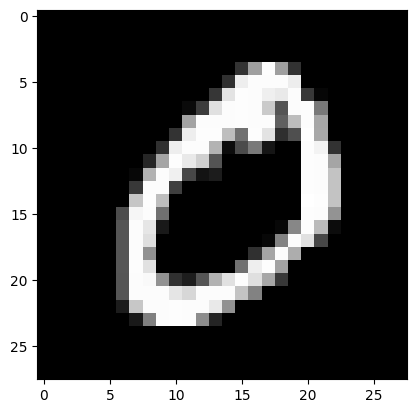

np.uint8(0)

(28, 28)

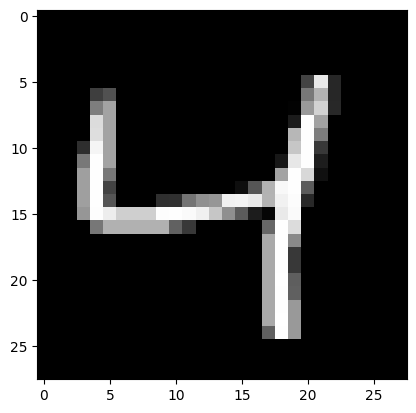

np.uint8(4)

(28, 28)

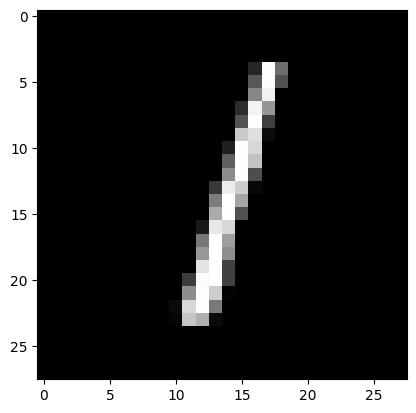

np.uint8(1)

(28, 28)

In [7]:
import matplotlib.pyplot as plt

plt.imshow(x_train[1], cmap = 'gray')
plt.show()
display(y_train[1])
display(x_train[1].shape)

plt.imshow(x_train[2], cmap = 'gray')
plt.show()
display(y_train[2])
display(x_train[2].shape)

plt.imshow(x_test[2], cmap = 'gray')
plt.show()
display(y_test[2])
display(x_test[2].shape)

In [8]:
### Turn all the pixels into features

# Flatten each 28x28 image into a 784-dimensional vector for use in a fully connected (Dense) neural network
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

# Convert pixel values to float32 to allow proper numerical computation during training
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# Normalize pixel values from [0, 255] to [0, 1] to improve training stability and convergence speed
x_train /= 255
x_test /= 255

print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')
x_test

60000 train samples
10000 test samples


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

<br>

### Build the model

In [9]:
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adam


batch_size = 64
num_classes = 10
epochs = 20


model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(784,)))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
#
# We're building a fully connected neural network with two hidden layers (16 and 32 neurons) using ReLU activation,
# where the input is a 784-dimensional vector (flattened image), and Dropout layers (20%) are added to reduce overfitting by randomly disabling neurons during training.
#

# Define the output layer
model.add(Dense(num_classes, activation='softmax'))


# Define the optimizer
my_opt = Adam(learning_rate=0.001)

model.compile(loss='categorical_crossentropy',
              optimizer = my_opt,  
              metrics=['accuracy'])


/Users/luis/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Display a summary of our deep Neural Network
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,434 (52.48 KB)

 Trainable params: 13,434 (52.48 KB)

 Non-trainable params: 0 (0.00 B)

<br>

### Train the model

In [11]:
# IF YOU RUN THIS TWICE; RELOAD THE DATA
# - to_categorical overwrites y_train/y_test in memory.
# - Running this cell twice will corrupt the labels. Re-run the load_data cell first if needed.

# convert class vectors to binary class matrices
y_train = tensorflow.keras.utils.to_categorical(y_train, num_classes)
y_test = tensorflow.keras.utils.to_categorical(y_test, num_classes)

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))



Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step - accuracy: 0.6035 - loss: 1.1905 - val_accuracy: 0.9138 - val_loss: 0.3076
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 590us/step - accuracy: 0.8329 - loss: 0.5305 - val_accuracy: 0.9229 - val_loss: 0.2669
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 617us/step - accuracy: 0.8559 - loss: 0.4675 - val_accuracy: 0.9257 - val_loss: 0.2513
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 636us/step - accuracy: 0.8632 - loss: 0.4381 - val_accuracy: 0.9298 - val_loss: 0.2300
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - accuracy: 0.8719 - loss: 0.4197 - val_accuracy: 0.9320 - val_loss: 0.2282
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 753us/step - accuracy: 0.8764 - loss: 0.4002 - val_accuracy: 0.9348 - val_loss: 0.2211
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 696us/step - accuracy: 0.8830 - loss: 0.3823 - val_accuracy: 0.9368 - val_loss: 0.2090
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step - accuracy: 0.8845 - loss: 0.3705 - 

### Evaluate the model

In [12]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.18286849558353424
Test accuracy: 0.9456999897956848


<br>

### Check overfitting

Let's check overfitting, by comparing the metrics on the train and test sets.

In [13]:
score_train = model.evaluate(x_train, y_train, verbose=0)
print('Train loss:', score_train[0])
print('Train accuracy:', score_train[1], "\n")

score_test = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score_test[0])
print('Test accuracy:', score_test[1], "\n")


Train loss: 0.15967072546482086
Train accuracy: 0.9529500007629395 

Test loss: 0.18286849558353424
Test accuracy: 0.9456999897956848 



Result: The model shows very mild overfitting (train accuracy > test accuracy, with a small gap).


<br>

#### Dropout

Dropout is a way to regularize the neural network. During training, it may happen that neurons of a particular layer may always become influenced only by the output of a particular neuron in the previous layer. In that case, the neural network would overfit.

Dropout prevents overfitting and regularizes by randomly cutting the connections (also known as dropping the connection) between neurons in successecutive layers during training.

<br>

## EXTRA: Keras optimizers



There are several variants of gradient descent, which differ in how we compute the step.

<br>

Keras supports seven optimizers.

```python
my_opt = tensorflow.keras.optimizers.SGD(lr=0.01, momentum=0.0, decay=0.0, nesterov=False)

my_opt = tensorflow.keras.optimizers.RMSprop(lr=0.001, rho=0.9, epsilon=None, decay=0.0)

my_opt = tensorflow.keras.optimizers.Adagrad(lr=0.01, epsilon=None, decay=0.0)

my_opt = tensorflow.keras.optimizers.Adadelta(lr=1.0, rho=0.95, epsilon=None, decay=0.0)

my_opt = tensorflow.keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)

my_opt = tensorflow.keras.optimizers.Adamax(lr=0.002, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0)

my_opt = tensorflow.keras.optimizers.Nadam(lr=0.002, beta_1=0.9, beta_2=0.999, epsilon=None, schedule_decay=0.004)
```

<br>
